# **TRABAJO DE FIN DE GRADO**
# **Tendencias emergentes en la transición energética española mediante análisis de publicaciones académicas**

## Facultad de Ciencias Empresariales. Universidad Pontificia Comillas ICADE

### NICOLA MASOTTI VILLANUEVA

## Instalación de paquetes y librerías

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q spacy pandas seaborn matplotlib pyLDAvis gensim nltk unidecode wordcloud
    !python -m spacy download en_core_web_sm
    !pip install -q pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 39.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.4 MB/s eta 0:00:00


In [2]:
#Procesamiento y limpieza
import pandas as pd
import numpy as np
import re
import string
from operator import itemgetter
from unidecode import unidecode

In [3]:
#NLP y text mining
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

import spacy
nlp = spacy.load('en_core_web_sm')

In [4]:
#Visualizaciones
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from IPython.display import display, HTML

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer #unigramas, bigramas, trigramas
from wordcloud import WordCloud, STOPWORDS #wordcloud

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [6]:
#Modelado de tópicos
from gensim.corpora import Dictionary
from gensim.models import LdaMulticore
from gensim.models.coherencemodel import CoherenceModel
import gensim

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
#ARIMA
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## Cargar datos

In [8]:
#leer CSV

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
textos = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TFG analytics/Corpus.csv')

Se han truncado las últimas 5000 líneas del flujo de salida.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcno

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [9]:
#Codigo para quitar todos los warnings
import warnings
import logging
import os
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [10]:
textos.head(10)

,Authors,Author full names,Author(s) ID,Title,Year,Link,Abstract,Author Keywords,Index Keywords
0,Jansen E.; Mišić M.; Schulze K.; Knodt M.; Pfe...,"Jansen, Erik (59972174700); Mišić, Mile (57213...",59972174700; 57213194255; 36169494500; 7801544...,Navigating the selection of renewable energy t...,2025,https://www.scopus.com/inward/record.uri?eid=2...,Decarbonizing economies and energy systems is ...,Energy security; Energy transition; Multi-obje...,NaN
1,Kiesecker J.M.; Evans J.S.; Oakleaf J.R.; Drop...,"Kiesecker, Joseph M. (7003392079); Evans, Jeff...",7003392079; 14043397000; 13604989900; 58997914...,Land use and Europe’s renewable energy transit...,2024,https://www.scopus.com/inward/record.uri?eid=2...,Continued dependence on imported fossil fuels ...,climate mitigation; development scenarios; ene...,NaN
2,Urrea Vivas M.A.; Seguí-Amórtegui L.; Guerrero...,"Urrea Vivas, M.A. (58645194800); Seguí-Amórteg...",58645194800; 55449560300; 8972543200,Analysis of greenhouse gas production at the E...,2025,https://www.scopus.com/inward/record.uri?eid=2...,The process of decarbonization of Wastewater T...,Carbon emissions accounting; CO<sub>2</sub> em...,Spain; Kyoto Protocol; Low emission; Carbon em...
3,Gómez A.F.; Rehage R.,"Gómez, Alba Forns (59481766700); Rehage, Ruben...",59481766700; 59481872800,Is Public Participation in Hydrogen Matters (U...,2024,https://www.scopus.com/inward/record.uri?eid=2...,The right to public participation was born as ...,Aarhus Convention; energy justice; equity; Eur...,NaN
4,Galiano Bastarrica L.A.; Buitrago Esquinas E.M...,"Galiano Bastarrica, Luis Antonio (57830256500)...",57830256500; 55293654400; 26429262200; 3610363...,An Integrated Assessment Model for comparing e...,2023,https://www.scopus.com/inward/record.uri?eid=2...,The decarbonisation of electricity supply pose...,Climate change; Decarbonisation; Energy policy...,Spain; Climate change; Climate models; Decarbo...
5,Beckstedde E.; Correa Ramírez M.; Cossent R.; ...,"Beckstedde, Ellen (57473377100); Correa Ramíre...",57473377100; 58307073600; 25929093100; 5598643...,Regulatory sandboxes: Do they speed up innovat...,2023,https://www.scopus.com/inward/record.uri?eid=2...,Regulatory sandboxes are generally seen as an ...,Energy regulation; Innovation; Regulatory expe...,Europe; Energy resources; Energy; Energy regul...
6,Roth F.; Topaloglou L.; Gabova S.; Bakouros Y....,"Roth, Florian (56388354100); Topaloglou, Lefte...",56388354100; 24466879200; 58794690200; 6506680...,Pondering the Promises & Problems of Participa...,2025,https://www.scopus.com/inward/record.uri?eid=2...,"To effectively address grand challenges, such ...",case studies; citizen panels; deliberation; le...,NaN
7,Brescia V.; Esposito P.; Amelio S.; Biancone P.P.,"Brescia, Valerio (57201307361); Esposito, Paol...",57201307361; 55647527700; 56192788000; 5704469...,Rethinking green investment and corporate sust...,2024,https://www.scopus.com/inward/record.uri?eid=2...,Purpose: The COVID-19 pandemic has generated a...,COVID-19; Energy; EU Next Generation; Green deal,NaN
8,Arizcuren-Blasco J.; Martin-Garcia R.; Ruiz-Ru...,"Arizcuren-Blasco, Javier (58205425600); Martin...",58205425600; 47561840900; 55351221600,Is unsubsidised energy transition possible? Fe...,2023,https://www.scopus.com/inward/record.uri?eid=2...,This study assesses the economic viability of ...,Decarbonisation; Electric vehicles; Public sub...,Aragon; Spain; Zaragoza; decision making; dies...
9,Okunevičiūtė Neverauskienė L.; Kvietkauskienė ...,"Okunevičiūtė Neverauskienė, Laima (36651545900...",36651545900; 57224473031; 10041082800; 5719309...,Evaluation of Renewable Energy Sources Sector ...,2025,https://www.scopus.com/inward/record.uri?eid=2...,"The global energy landscape is transforming, d...",economic development; EU countries; multi-crit...,Economic analysis; Economic and social effects...


# 0. Análisis evolución numero de publicaciones


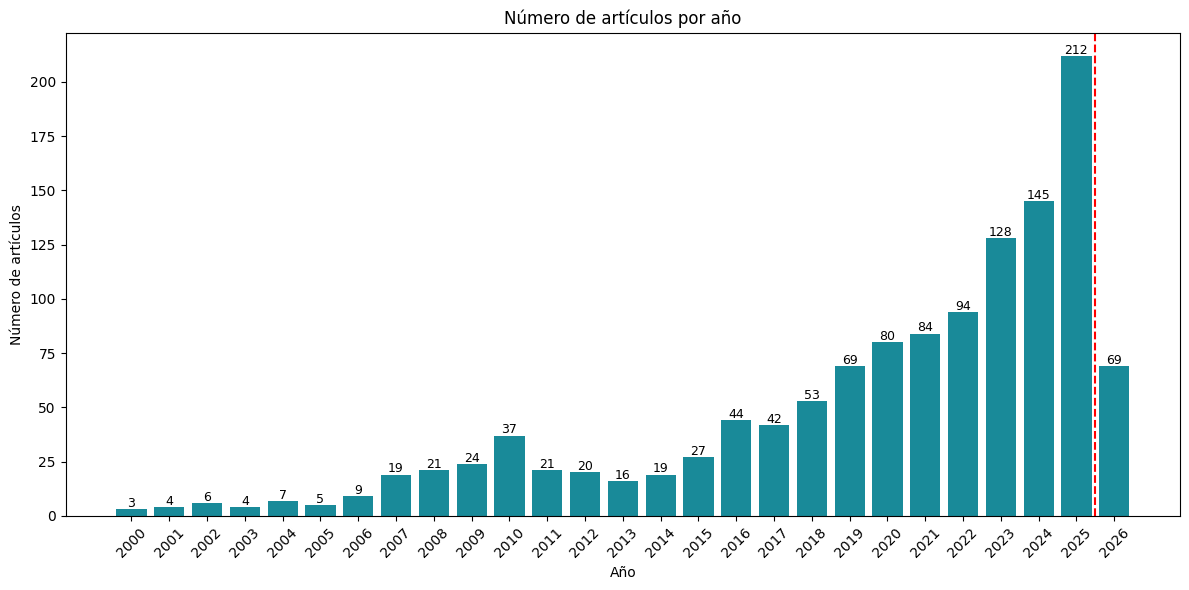

In [11]:
# Contar artículos por año
conteo = textos.groupby('Year').size()

# Graficar
plt.figure(figsize=(12, 6))
bars = plt.bar(conteo.index.astype(str), conteo.values, color='#198A99')
plt.title('Número de artículos por año')
plt.xlabel('Año')
plt.ylabel('Número de artículos')
plt.xticks(rotation=45)
indice_2026 = list(conteo.index.astype(str)).index('2026')
plt.axvline(x=indice_2026 - 0.5, color='red', linestyle='--', linewidth=1.5)
for x, y in zip(conteo.index.astype(str), conteo.values):
    plt.text(x, y + 1, str(y), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 1. PREPROCESAMIENTO Y LIMPIEZA DE DATOS

In [12]:
#Filtrar artículos anteriores a 2000
textos = textos[textos['Year'] >= 2000]

#Eliminar abstracts vacíos o no disponibles
textos = textos[textos['Abstract'].notna()]
textos = textos[~textos['Abstract'].str.contains('NaN', case=False, na=False)]
textos = textos[textos['Abstract'].str.len() > 100]

#Eliminar duplicados por título
textos = textos.drop_duplicates(subset='Title')
textos = textos.reset_index(drop=True)
textos.head(10)

,Authors,Author full names,Author(s) ID,Title,Year,Link,Abstract,Author Keywords,Index Keywords
0,Kiesecker J.M.; Evans J.S.; Oakleaf J.R.; Drop...,"Kiesecker, Joseph M. (7003392079); Evans, Jeff...",7003392079; 14043397000; 13604989900; 58997914...,Land use and Europe’s renewable energy transit...,2024,https://www.scopus.com/inward/record.uri?eid=2...,Continued dependence on imported fossil fuels ...,climate mitigation; development scenarios; ene...,NaN
1,Urrea Vivas M.A.; Seguí-Amórtegui L.; Guerrero...,"Urrea Vivas, M.A. (58645194800); Seguí-Amórteg...",58645194800; 55449560300; 8972543200,Analysis of greenhouse gas production at the E...,2025,https://www.scopus.com/inward/record.uri?eid=2...,The process of decarbonization of Wastewater T...,Carbon emissions accounting; CO<sub>2</sub> em...,Spain; Kyoto Protocol; Low emission; Carbon em...
2,Gómez A.F.; Rehage R.,"Gómez, Alba Forns (59481766700); Rehage, Ruben...",59481766700; 59481872800,Is Public Participation in Hydrogen Matters (U...,2024,https://www.scopus.com/inward/record.uri?eid=2...,The right to public participation was born as ...,Aarhus Convention; energy justice; equity; Eur...,NaN
3,Galiano Bastarrica L.A.; Buitrago Esquinas E.M...,"Galiano Bastarrica, Luis Antonio (57830256500)...",57830256500; 55293654400; 26429262200; 3610363...,An Integrated Assessment Model for comparing e...,2023,https://www.scopus.com/inward/record.uri?eid=2...,The decarbonisation of electricity supply pose...,Climate change; Decarbonisation; Energy policy...,Spain; Climate change; Climate models; Decarbo...
4,Beckstedde E.; Correa Ramírez M.; Cossent R.; ...,"Beckstedde, Ellen (57473377100); Correa Ramíre...",57473377100; 58307073600; 25929093100; 5598643...,Regulatory sandboxes: Do they speed up innovat...,2023,https://www.scopus.com/inward/record.uri?eid=2...,Regulatory sandboxes are generally seen as an ...,Energy regulation; Innovation; Regulatory expe...,Europe; Energy resources; Energy; Energy regul...
5,Roth F.; Topaloglou L.; Gabova S.; Bakouros Y....,"Roth, Florian (56388354100); Topaloglou, Lefte...",56388354100; 24466879200; 58794690200; 6506680...,Pondering the Promises & Problems of Participa...,2025,https://www.scopus.com/inward/record.uri?eid=2...,"To effectively address grand challenges, such ...",case studies; citizen panels; deliberation; le...,NaN
6,García-Gusano D.; Iribarren D.; Muñoz I.; Arri...,"García-Gusano, Diego (55951748100); Iribarren,...",55951748100; 25722122300; 57204012174; 5646315...,The future need for critical raw materials ass...,2025,https://www.scopus.com/inward/record.uri?eid=2...,The deployment of renewable energy technologie...,critical raw material; Decarbonisation; energy...,Spain; Case-studies; Critical raw materials; D...
7,Gallego-Castillo C.; Victoria M.,"Gallego-Castillo, Cristobal (56245272600); Vic...",56245272600; 26530630500,PyPSA-Spain: An extension of PyPSA-Eur to mode...,2025,https://www.scopus.com/inward/record.uri?eid=2...,"This work presents PyPSA-Spain, an open-source...",Energy system modelling; Open-source; Spanish ...,Electricity demands; Energy; Energy systems; E...
8,de Juan I.; Hidalgo-Giralt C.; Palacios-García A.,"de Juan, Ibai (59223531000); Hidalgo-Giralt, C...",59223531000; 57209270319; 56321112300,Constraints to Energy Transition in Metropolit...,2025,https://www.scopus.com/inward/record.uri?eid=2...,Amidst the backdrop of the fossil fuel energy ...,energy transition; land-use; mineral footprint...,NaN
9,Paredes Á.; Zhou Y.; Aguado J.A.; Morstyn T.,"Paredes, Ángel (57217148959); Zhou, Yihong (57...",57217148959; 57222128696; 57038204200; 5639699...,Independent aggregators securing end user Wass...,2026,https://www.scopus.com/inward/record.uri?eid=2...,The imperative for increased power system flex...,Aggregation; Chance constraints; Delivery guar...,Commerce; Distributed energy; Energy resources...


In [13]:
#Quitamos las columnas innecesarias
textos = textos.drop(columns=['Title', 'Link', 'Author(s) ID', 'Authors', 'Author full names','Author Keywords', 'Index Keywords'], errors='ignore')
textos.head()

,Year,Abstract
0,2024,Continued dependence on imported fossil fuels ...
1,2025,The process of decarbonization of Wastewater T...
2,2024,The right to public participation was born as ...
3,2023,The decarbonisation of electricity supply pose...
4,2023,Regulatory sandboxes are generally seen as an ...


In [14]:
# Eliminar ruido editorial — Scopus incluye textos de copyright al final de los abstracts
textos['Abstract'] = textos['Abstract'].str.replace(r'©.*', '', regex=True)
textos['Abstract'] = textos['Abstract'].str.replace(
    r'(?i)\.?\s*(all rights reserved|published by|licensee|this is an open access'
    r'|open access article|under the terms|creative commons|cc by).*', '', regex=True)
textos['Abstract'] = textos['Abstract'].str.replace(
    r'(?i)\s*(elsevier|springer|wiley|taylor\s*&?\s*francis|mdpi|frontiers|emerald|sage|informa)'
    r'\s*(ltd|bv|inc|gmbh)?\s*\.?\s*$', '', regex=True)
textos['Abstract'] = textos['Abstract'].str.replace(
    r'Copyright',
    r'', regex=True)
textos['Abstract'] = textos['Abstract'].str.strip()
textos['Abstract'] = textos['Abstract'].astype(str)
textos.head(10)

,Year,Abstract
0,2024,Continued dependence on imported fossil fuels ...
1,2025,The process of decarbonization of Wastewater T...
2,2024,The right to public participation was born as ...
3,2023,The decarbonisation of electricity supply pose...
4,2023,Regulatory sandboxes are generally seen as an ...
5,2025,"To effectively address grand challenges, such ..."
6,2025,The deployment of renewable energy technologie...
7,2025,"This work presents PyPSA-Spain, an open-source..."
8,2025,Amidst the backdrop of the fossil fuel energy ...
9,2026,The imperative for increased power system flex...


In [15]:
# Reemplazos usando expresiones regulares
# Solo agrupamos expresiones compuestas que el LDA trataría como palabras separadas
textos['Abstract'] = textos['Abstract'].str.replace(r'(?i)renewable energy',     'renewable_energy',   regex=True)
textos['Abstract'] = textos['Abstract'].str.replace(r'(?i)energy transition',    'energy_transition',  regex=True)
textos['Abstract'] = textos['Abstract'].str.replace(r'(?i)solar\s*photovoltaic|photovoltaic', 'solar_photovoltaic', regex=True)
textos['Abstract'] = textos['Abstract'].str.replace(r'(?i)wind energy|wind power',          'wind_energy',        regex=True)
textos['Abstract'] = textos['Abstract'].str.replace(r'(?i)energy efficiency',    'energy_efficiency',  regex=True)
textos['Abstract'] = textos['Abstract'].str.replace(r'(?i)energy storage',       'energy_storage',     regex=True)
textos['Abstract'] = textos['Abstract'].str.replace(r'(?i)greenhouse gas|ghg',       'greenhouse_gas',     regex=True)
textos['Abstract'] = textos['Abstract'].str.replace(r'(?i)fossil fuel',          'fossil_fuel',        regex=True)
textos['Abstract'] = textos['Abstract'].str.replace(r'(?i)electric vehicle',     'electric_vehicle',   regex=True)
textos['Abstract'] = textos['Abstract'].str.replace(r'(?i)climate change',       'climate_change',     regex=True)
textos['Abstract'] = textos['Abstract'].str.replace(r'(?i)heat pump',            'heat_pump',          regex=True)
textos['Abstract'] = textos['Abstract'].str.replace(r'(?i)self consumption',    'self_consumption',   regex=True)
textos['Abstract'] = textos['Abstract'].str.replace(r'(?i)paris agreement',      'paris_agreement',    regex=True)
textos['Abstract'] = textos['Abstract'].astype(str)
textos.head(10)

,Year,Abstract
0,2024,Continued dependence on imported fossil_fuels ...
1,2025,The process of decarbonization of Wastewater T...
2,2024,The right to public participation was born as ...
3,2023,The decarbonisation of electricity supply pose...
4,2023,Regulatory sandboxes are generally seen as an ...
5,2025,"To effectively address grand challenges, such ..."
6,2025,The deployment of renewable_energy technologie...
7,2025,"This work presents PyPSA-Spain, an open-source..."
8,2025,Amidst the backdrop of the fossil_fuel energy ...
9,2026,The imperative for increased power system flex...


In [16]:
#Stopwords
stop_words = set(stopwords.words('english') + [
    'spain', 'spanish' , 'study', 'paper' , 'policy', 'energy', 'transition',
    'decarbonization', 'decarbonisation', 'analyze', 'analyse', 'analysis',
    'purpose', 'propose', 'approach','semi', 'structured', 'interview', 'lmdi',
    'result', 'system', 'model', 'based', 'datum', 'aim', 'compare', 'approach',
    'method', 'assess', 'base', 'assessment'
])

In [17]:
nlp = spacy.load('en_core_web_sm')

# Función de limpieza completa
def process_text_spacy(text):
    text = unidecode(text.lower())  # Normalizar y pasar a minúsculas, quita tildes
    text = re.sub(r'[^a-z\s_]', ' ', text)  # eliminar dígitos y puntuación
    text = re.sub(r'\s+', ' ', text).strip()

    doc = nlp(text) #tokenización

    # Lematizar y filtrar (sin stopwords, sin puntuación, sin pronombres)
    lemmas = [token.lemma_ for token in doc
        if not token.is_stop and not token.is_punct
        and token.pos_ != 'PRON' and token.lemma_.isalpha()
        and token.lemma_.lower() not in stop_words
        and len(token.lemma_) > 2]

    # Quitar duplicados manteniendo el orden
    seen = set()
    unique_lemmas = []
    for w in lemmas:
        if w not in seen:
            seen.add(w)
            unique_lemmas.append(w)

    return unique_lemmas

In [18]:
textos['lemmas'] = textos['Abstract'].astype(str).apply(process_text_spacy)
textos.head(20)

,Year,Abstract,lemmas
0,2024,Continued dependence on imported fossil_fuels ...,"[continue, dependence, import, rapidly, unsust..."
1,2025,The process of decarbonization of Wastewater T...,"[process, wastewater, treatment, plant, wwtps,..."
2,2024,The right to public participation was born as ...,"[right, public, participation, bear, participa..."
3,2023,The decarbonisation of electricity supply pose...,"[electricity, supply, pose, major, milestone, ..."
4,2023,Regulatory sandboxes are generally seen as an ...,"[regulatory, sandbox, generally, see, importan..."
5,2025,"To effectively address grand challenges, such ...","[effectively, address, grand, challenge, digit..."
6,2025,The deployment of renewable_energy technologie...,"[deployment, technology, necessary, decarbonis..."
7,2025,"This work presents PyPSA-Spain, an open-source...","[work, present, pypsa, open, source, high, res..."
8,2025,Amidst the backdrop of the fossil_fuel energy ...,"[amidst, backdrop, crisis, development, source..."
9,2026,The imperative for increased power system flex...,"[imperative, increase, power, flexibility, dri..."


In [19]:
# Convertir la lista de lemas en una cadena de texto (string).
# Necesario porque WordCloud y TfidfVectorizer requieren strings, no listas.
# Para el modelado LDA usaremos la columna 'lemmas' directamente (lista).
textos['lemmas_str'] = textos['lemmas'].apply(lambda x: ' '.join(x))
textos['lemmas_str'] = textos['lemmas_str'].fillna('').astype('string')

# 2. ANÁLISIS EXPLORATORIO

## 2.2 WORDCLOUD

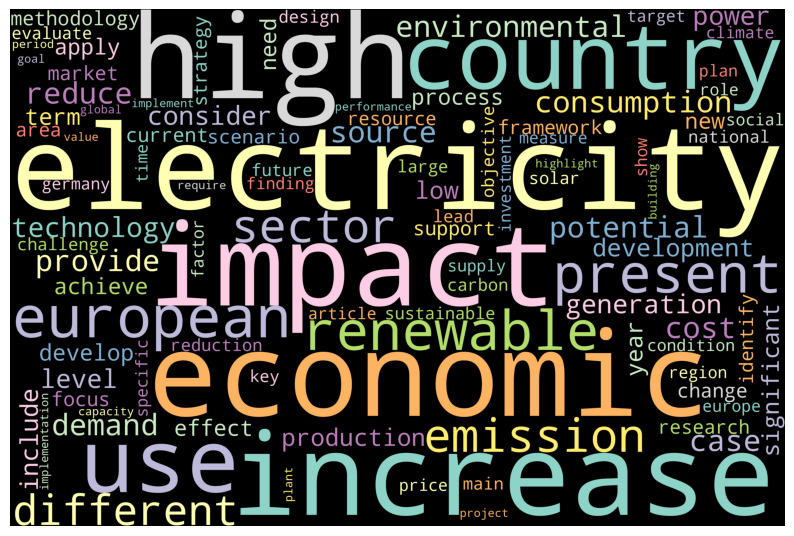

In [20]:
#Funcion para pintar el Wordcloud
def plot_cloud(wordcloud):
    plt.figure(figsize=(10, 7))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.show()

#Pintamos el wordcloud
wordcloud = WordCloud(width=3000, height=2000, random_state=1, max_words=100,
    background_color='black', colormap='Set3', collocations=False,
    stopwords=STOPWORDS).generate(' '.join(textos['lemmas_str']))
plot_cloud(wordcloud)

## 2.2 ANALISIS N-GRAMAS

In [21]:
#Creamos una lista con los valores de la columna 'lemmas_str', excluyendo los valores "nan"
dft = textos['lemmas_str']
dft = [x for x in dft if str(x) != 'nan']

### Unigramas

electricity 19.992669372225045
economic 19.31101048030883
country 18.840305830573357
increase 18.760828412363686
high 18.662758944697426
impact 18.627716437551246
sector 18.295071874660096
renewable 18.1269549958691
different 17.982931518732972
emission 17.954355876337956
present 17.868620016950196
use 17.854619695222024
european 17.83844892417174
consumption 17.648779419090516
case 17.330970590981366
cost 17.19809268803089
demand 17.170897151297478
reduce 17.012344190181235
source 16.975911686842874
technology 16.76707372602985
environmental 16.552034025955862
provide 16.519585816742143
generation 16.422089509959658
consider 16.31956230526213
potential 16.2075340616629
power 16.190166569826065
level 15.812533956265296
development 15.713807559701984
production 15.431198225862827
include 15.40610073550709


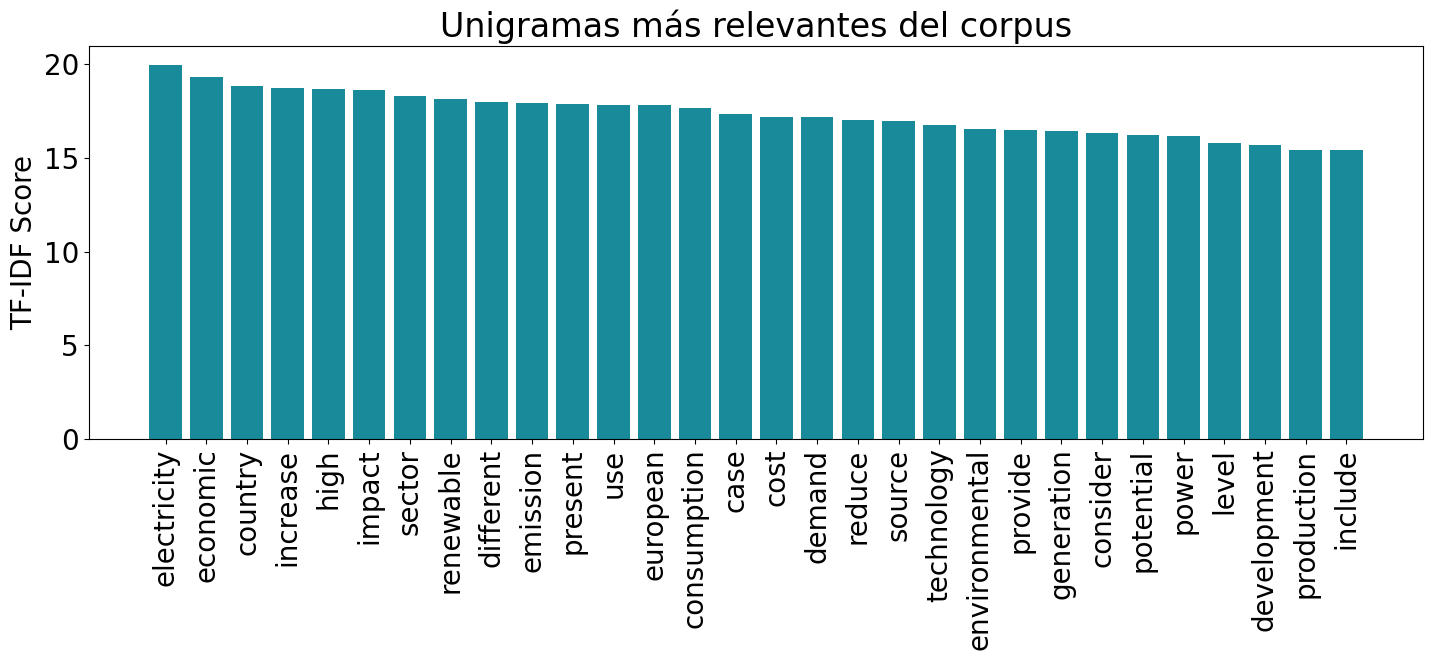

In [22]:
#Se calculan el Valor de TF-IDF de los unigramas
tfIdfVectorizer = TfidfVectorizer(use_idf=True, ngram_range=(1,1))
tfIdf = tfIdfVectorizer.fit_transform(dft)
names = tfIdfVectorizer.get_feature_names_out()
freqs = tfIdf.sum(axis=0).A1
result = dict(zip(names, freqs))

# Obtenemos las 30 palabras más relevantes aplicando TF-IDF
i = 0
results_sorted = sorted(result.items(), key=itemgetter(1), reverse=True)
for key, value in results_sorted:
    i += 1
    if i == 31:
        break
    print(key, value)

#Dibujamos los unigramas más relevantes
df_results = pd.DataFrame.from_dict(results_sorted).head(30)
plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(15, 7))
plt.bar(df_results[0], df_results[1], color='#198A99')
plt.xticks(rotation=90)
plt.ylabel('TF-IDF Score')
plt.title('Unigramas más relevantes del corpus')
plt.tight_layout()
plt.show()

### Bigramas

european union 5.863219089327439
long term 3.7917854635048895
life cycle 3.4781694106013843
environmental impact 3.255425388693267
take account 2.7993646294893315
low carbon 2.77370599326414
natural gas 2.73726545902169
member state 2.733458414266765
self consumption 2.62759824846346
electricity generation 2.5916465769877455
power plant 2.5242374645986687
renewable source 2.5237688207996576
sustainable development 2.510507600847777
feed tariff 2.4585379027211265
united kingdom 2.3936245917987535
france germany 2.3651345330981717
input output 2.3648642596816605
reduce emission 2.3044544436381798
regulatory framework 2.2343778065926494
global warming 2.19825115569064
large scale 2.171435565779507
recent year 2.158229640983937
european country 2.078824071401151
germany italy 2.050435146582837
economic environmental 2.040678411510148
decision making 1.9156940658445498
techno economic 1.9053766731056563
electricity market 1.8533710602680233
technical economic 1.8186737836613065
decision mak

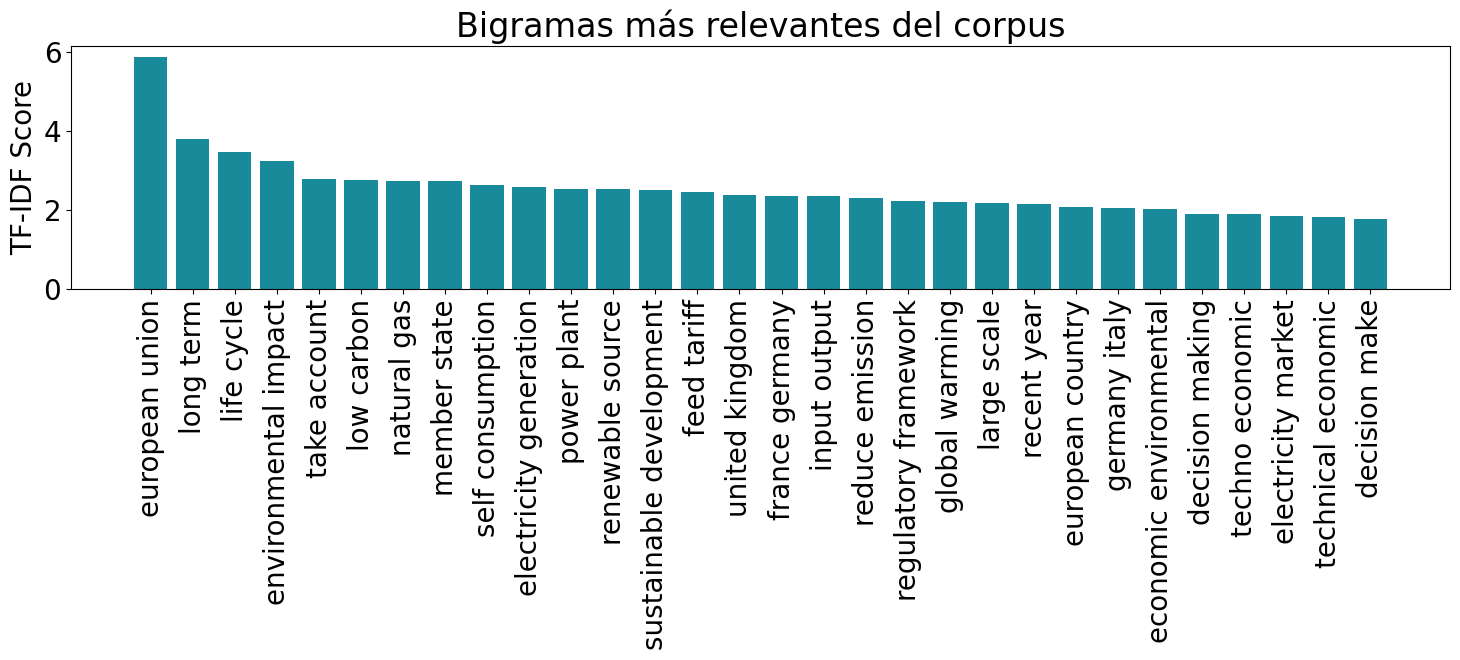

In [23]:
tfIdfVectorizer_bi = TfidfVectorizer(use_idf=True, ngram_range=(2,2))
tfIdf_bi = tfIdfVectorizer_bi.fit_transform(dft)
names_bi = tfIdfVectorizer_bi.get_feature_names_out()
freqs_bi = tfIdf_bi.sum(axis=0).A1
result_bi = dict(zip(names_bi, freqs_bi))

i = 0
results_sorted = sorted(result_bi.items(), key=itemgetter(1), reverse=True)
for key, value in results_sorted:
    i += 1
    if i == 31:
        break
    print(key, value)

results_sorted_bi = sorted(result_bi.items(), key=itemgetter(1), reverse=True)
df_results_bi = pd.DataFrame.from_dict(results_sorted_bi).head(30)
plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(15, 7))
plt.bar(df_results_bi[0], df_results_bi[1], color='#198A99')
plt.xticks(rotation=90)
plt.ylabel('TF-IDF Score')
plt.title('Bigramas más relevantes del corpus')
plt.tight_layout()
plt.show()

### Trigramas

france germany italy 1.250039076594692
play important role 1.2215927731066922
play key role 1.1642272941608982
germany france italy 1.0211733821225037
engineering resource management 1.0
net present value 0.9871767209861837
life cycle lca 0.9598975951582752
play crucial role 0.9013325225804197
carbon dioxide emission 0.8804635474403651
domestic hot water 0.8764337516766665
feed tariff fit 0.8670428407756466
internal rate return 0.8326883732641948
gross domestic product 0.8172822615370254
national climate plan 0.8023786669473931
mean divisia index 0.7612044286860106
computable general equilibrium 0.7412467514261699
mixed integer linear 0.718406100029042
european green deal 0.7163675524757955
input output table 0.7093478812566316
germany italy poland 0.6860498258563928
logarithmic mean divisia 0.6842117823173849
solar power csp 0.6751266535363911
country france germany 0.6622359043729321
global warming potential 0.6589036834233981
net zero emission 0.6517225450847797
low carbon economy 0

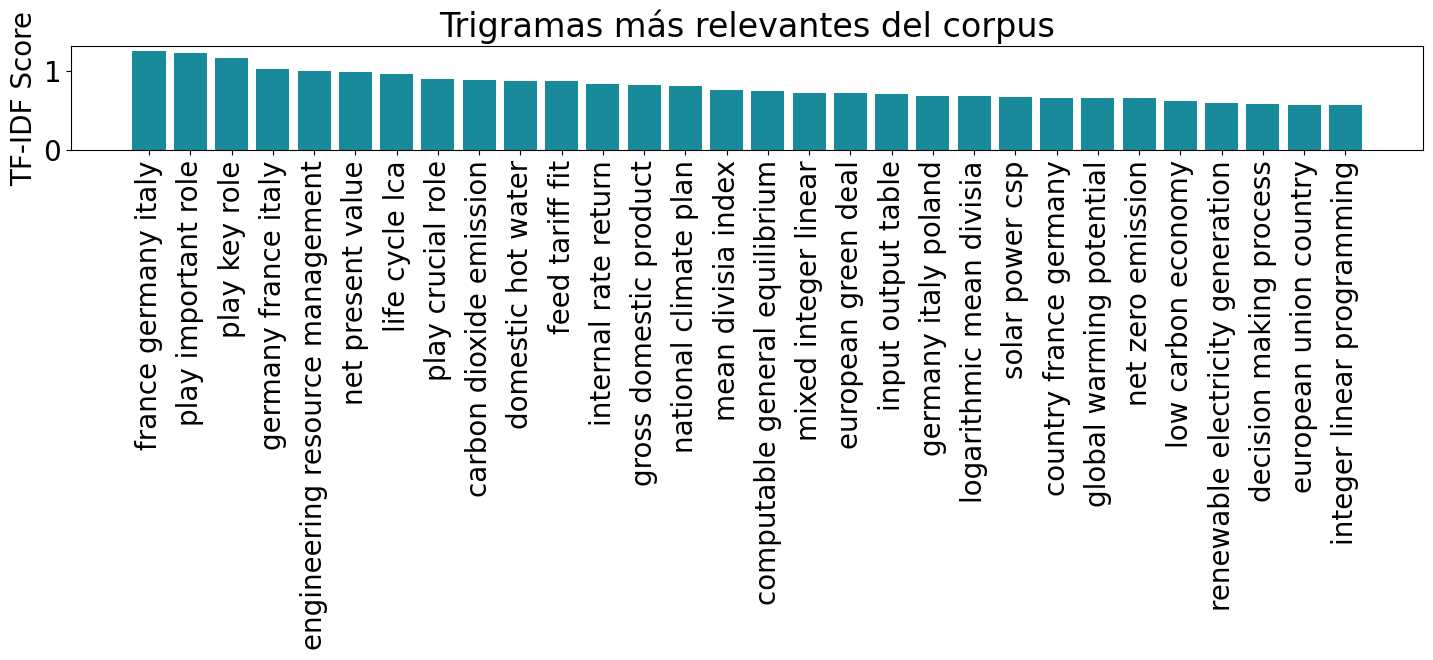

In [24]:
tfIdfVectorizer_tri = TfidfVectorizer(use_idf=True, ngram_range=(3,3))
tfIdf_tri = tfIdfVectorizer_tri.fit_transform(dft)
names_tri = tfIdfVectorizer_tri.get_feature_names_out()
freqs_tri = tfIdf_tri.sum(axis=0).A1
result_tri = dict(zip(names_tri, freqs_tri))

i = 0
results_sorted = sorted(result_tri.items(), key=itemgetter(1), reverse=True)
for key, value in results_sorted:
    i += 1
    if i == 31:
        break
    print(key, value)

results_sorted_tri = sorted(result_tri.items(), key=itemgetter(1), reverse=True)
df_results_tri = pd.DataFrame.from_dict(results_sorted_tri).head(30)
plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(15, 7))
plt.bar(df_results_tri[0], df_results_tri[1], color='#198A99')
plt.xticks(rotation=90)
plt.ylabel('TF-IDF Score')
plt.title('Trigramas más relevantes del corpus')
plt.tight_layout()
plt.show()

# 3. MODELADO DE TÓPICOS

La columna 'lemmas' ya contiene listas de tokens — se usa directamente para gensim.
La conversión a string que hicimos en 'lemmas_str' era solo para TF-IDF y WordCloud.

In [25]:
from random import seed
seed(52) #semilla reproducibilidad

# Creamos el diccionario de palabras
id2word = Dictionary(textos['lemmas'])
id2word.filter_extremes(no_below=5, no_above=.75) # Eliminamos palabras muy raras o muy frecuentes

#Se crea el objeto corpus
corpus = [id2word.doc2bow(d) for d in textos['lemmas']]

print(f'✓ Diccionario: {len(id2word)} términos únicos')
print(f'✓ Corpus BOW: {len(corpus)} documentos')

✓ Diccionario: 2313 términos únicos
✓ Corpus BOW: 1040 documentos


## Valor óptimo de k

In [26]:
#Funcion para encontrar el valor optimo de k
def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=1):
    coherence_values_topic = [] #se van guardando la coherencia de cada modelo con los diferentes num de k
    model_list_topic = []
    for num_topics in range(start, limit, step):
        model = LdaMulticore(corpus=corpus, num_topics=num_topics, id2word=id2word,
                             passes=10, workers=1, random_state=52)
        model_list_topic.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values_topic.append(coherencemodel.get_coherence())
        print(f'K={num_topics} → Coherencia Cv: {coherence_values_topic[-1]:.4f}')

    return model_list_topic, coherence_values_topic

In [27]:
#Se aplica la función definida en el paso anterior
model_list_topic, coherence_values_topic = compute_coherence_values(
    dictionary=id2word, corpus=corpus, texts=textos['lemmas'],
    start=2, limit=9, step=1)

K=2 → Coherencia Cv: 0.3233
K=3 → Coherencia Cv: 0.3758
K=4 → Coherencia Cv: 0.3396
K=5 → Coherencia Cv: 0.3625
K=6 → Coherencia Cv: 0.3671
K=7 → Coherencia Cv: 0.3745
K=8 → Coherencia Cv: 0.3464


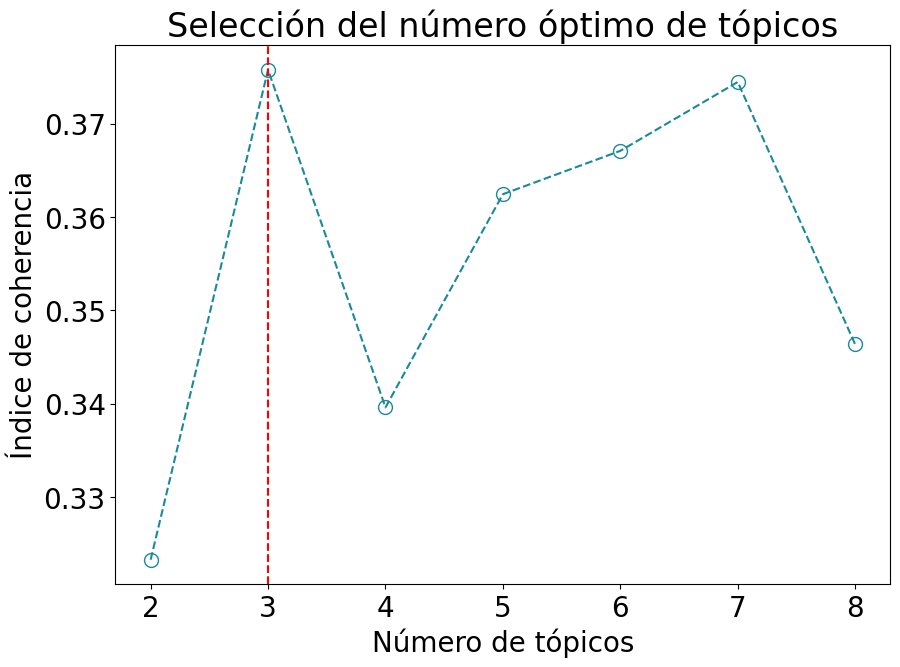

K óptimo: 3 (Cv=0.3758)


In [28]:
#Graficamos para buscar K optimo
k_optimo_auto = coherence_values_topic.index(max(coherence_values_topic)) + 2

plt.figure(figsize=(10, 7))
plt.plot(range(2, 9), coherence_values_topic, '#198A99',
         marker='o', markersize=10, fillstyle='none', linestyle='--')
plt.axvline(x=k_optimo_auto, color='r', linestyle='--', linewidth=1.5)
plt.xlabel('Número de tópicos')
plt.ylabel('Índice de coherencia')
plt.title('Selección del número óptimo de tópicos')
plt.show()

print(f'K óptimo: {k_optimo_auto} (Cv={max(coherence_values_topic):.4f})')

## Modelo LDA

In [29]:
#Se genera el modelo LDA con el número de k elegido, ajusta si lo consideras oportuno
k = k_optimo_auto

#Recuperamos el modelo ya entrenado para ese K (sin reentrenar)
model_k = model_list_topic[k - 2]

#Se procede a guardar y cargar todos los resultados obtenidos del modelo
model_k.save('model_lda.model')

In [30]:
#Luego, cargamos el modelo guardado desde el archivo
model_k_load = LdaMulticore.load('model_lda.model')

In [31]:
#Computamos la coherencia global del modelo
coherence_model_k = CoherenceModel(model=model_k_load, texts=textos['lemmas'],
                                   dictionary=id2word, coherence='c_v')
coherence_model_k = coherence_model_k.get_coherence()
print('\nCoherence Score: ', coherence_model_k)


Coherence Score:  0.375799249731183


In [32]:
#Se observan las 10 palabras más utilizadas en cada tópico
print(model_k_load.print_topics())
doc_lda = model_k_load[corpus]
#Se filtra por palabras
words = [re.findall(r'"([^"]*)"', t[1]) for t in model_k_load.print_topics()]
#Se crean los tópicos
topics = [' '.join(t[0:10]) for t in words]
for id, t in enumerate(topics):
    print(f"------ Topic {id} ------")
    print(t, end="\n\n")

[(0, '0.005*"case" + 0.005*"electricity" + 0.005*"power" + 0.005*"generation" + 0.004*"new" + 0.004*"renewable" + 0.004*"cost" + 0.004*"different" + 0.004*"framework" + 0.004*"technology"'), (1, '0.007*"emission" + 0.006*"high" + 0.006*"electricity" + 0.005*"present" + 0.005*"use" + 0.005*"reduce" + 0.005*"economic" + 0.005*"demand" + 0.005*"potential" + 0.005*"cost"'), (2, '0.007*"country" + 0.006*"european" + 0.005*"impact" + 0.005*"increase" + 0.005*"germany" + 0.005*"sector" + 0.004*"level" + 0.004*"development" + 0.004*"economic" + 0.004*"effect"')]
------ Topic 0 ------
case electricity power generation new renewable cost different framework technology

------ Topic 1 ------
emission high electricity present use reduce economic demand potential cost

------ Topic 2 ------
country european impact increase germany sector level development economic effect



In [33]:
#Pintamos la distancia intertópica con pyLDAvis
pyLDAvis.enable_notebook()

In [34]:
gensimvis.prepare(model_k_load, corpus, id2word)

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
1      0.053577 -0.028643       1        1  40.28112
2     -0.055272 -0.026087       2        1  36.64084
0      0.001695  0.054729       3        1  23.07804, topic_info=         Term        Freq       Total Category  logprob  loglift
54      italy  108.000000  108.000000  Default  30.0000  30.0000
39    germany  150.000000  150.000000  Default  29.0000  29.0000
775      grid  111.000000  111.000000  Default  28.0000  28.0000
35     france   98.000000   98.000000  Default  27.0000  27.0000
129  emission  284.000000  284.000000  Default  26.0000  26.0000
..        ...         ...         ...      ...      ...      ...
46       high   56.038691  322.810484   Topic3  -5.6732  -0.2847
159       use   53.353587  290.066140   Topic3  -5.7223  -0.2269
429  resource   49.481560  169.103430   Topic3  -5.7976   0.2374
53   increase   50.818000  307.242952   Topic3  -5.7710  -0.3331
178  european   50.417341  285.113901   Topic3  -5.7789  -0.2663

[297 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
1875      2  0.174420     accept
1875      3  0.872101     accept
2150      2  0.917052  accompany
214       1  0.479631    achieve
214       2  0.254804    achieve
...     ...       ...        ...
161       2  0.058994      water
161       3  0.106189      water
363       1  0.500078       year
363       2  0.292499       year
363       3  0.207580       year

[593 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 1])

In [35]:
#Se añade una columna de LDA features al modelo cargado
def document_to_lda_features(model_k_load, document):
    topic_importance = np.array(model_k_load.get_document_topics(document, minimum_probability=0))
    return topic_importance[:, 1]

textos['lda_features'] = list(map(lambda doc: document_to_lda_features(model_k_load, doc), corpus))

## Temas dominantes e interpretación

In [36]:
#Cuál es el tema dominante: ¿Cuál es el valor más alto en la lista de proporciones?
def topic_important(item_score):
    score = np.argmax(item_score, axis=0)
    return score

In [37]:
#Vemos que topico se ajusta mas a cada documento
textos['topic_dominant'] = textos['lda_features'].apply(topic_important)
textos.head(10)
##Se genera un csv con los resultados
textos.to_csv('resultados.csv', index=False)

In [38]:
#Se saca el número de articulos por tópico
textos['topic_dominant'].value_counts()

,count
topic_dominant,
1,408
2,403
0,229


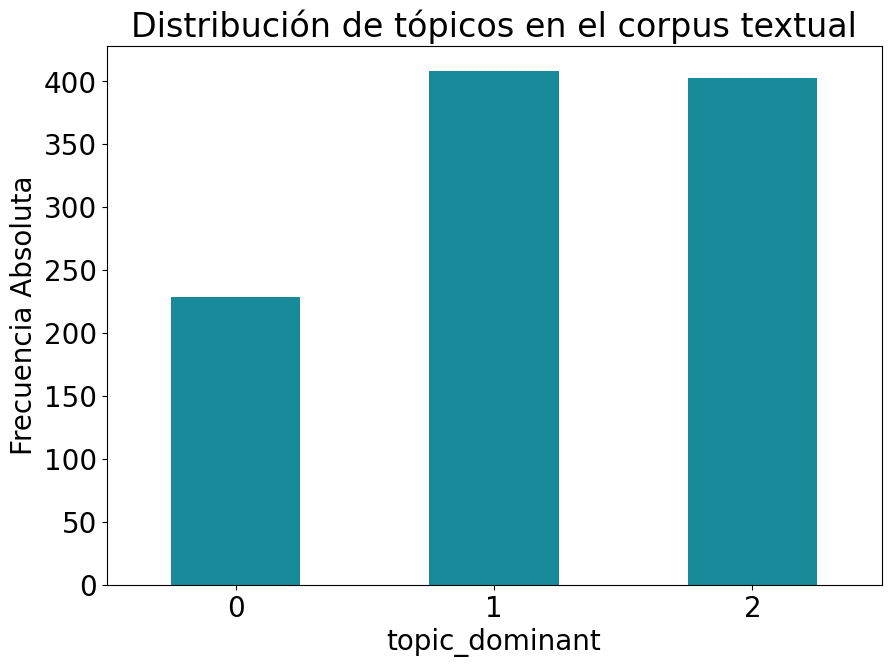

In [39]:
#Grafica nº de articulos por topico
plt.figure(figsize=(10, 7))
ax = textos['topic_dominant'].value_counts().sort_index().plot(kind='bar', color='#198A99')
plt.ylabel('Frecuencia Absoluta')
plt.title('Distribución de tópicos en el corpus textual')
plt.xticks(rotation=0)
plt.show()

Sacamos bigramas y trigramas por tópicos para una mejor interpretación.

In [40]:
#Para cada topico, calculamos los valores TF-IDF de los lemmas, sacamos y ploteamos los bigramas más relevantes
def plot_bigramas_por_topico(textos, topico, top_n=30):

    topic_df = textos[textos['topic_dominant'] == topico]
    dft = topic_df['lemmas_str']
    dft = [x for x in dft if str(x) != 'nan']

    # Vectorizar bigramas con TF-IDF
    tfIdfVectorizer_bi = TfidfVectorizer(use_idf=True, ngram_range=(2, 2))
    tfIdf_bi = tfIdfVectorizer_bi.fit_transform(dft)
    names_bi = tfIdfVectorizer_bi.get_feature_names_out()
    freqs_bi = tfIdf_bi.sum(axis=0).A1
    result_bi = dict(zip(names_bi, freqs_bi))

    from operator import itemgetter
    results_sorted_bi = sorted(result_bi.items(), key=itemgetter(1), reverse=True)

    df_results_bi = pd.DataFrame(results_sorted_bi).head(30)
    plt.rcParams.update({'font.size': 20})
    plt.figure(figsize=(15, 7))
    plt.bar(df_results_bi[0], df_results_bi[1], color='#198A99')
    plt.xticks(rotation=90)
    plt.ylabel('TF-IDF Score')
    plt.title(f'Bigramas más relevantes en el tópico {topico}')
    plt.tight_layout()
    plt.show()

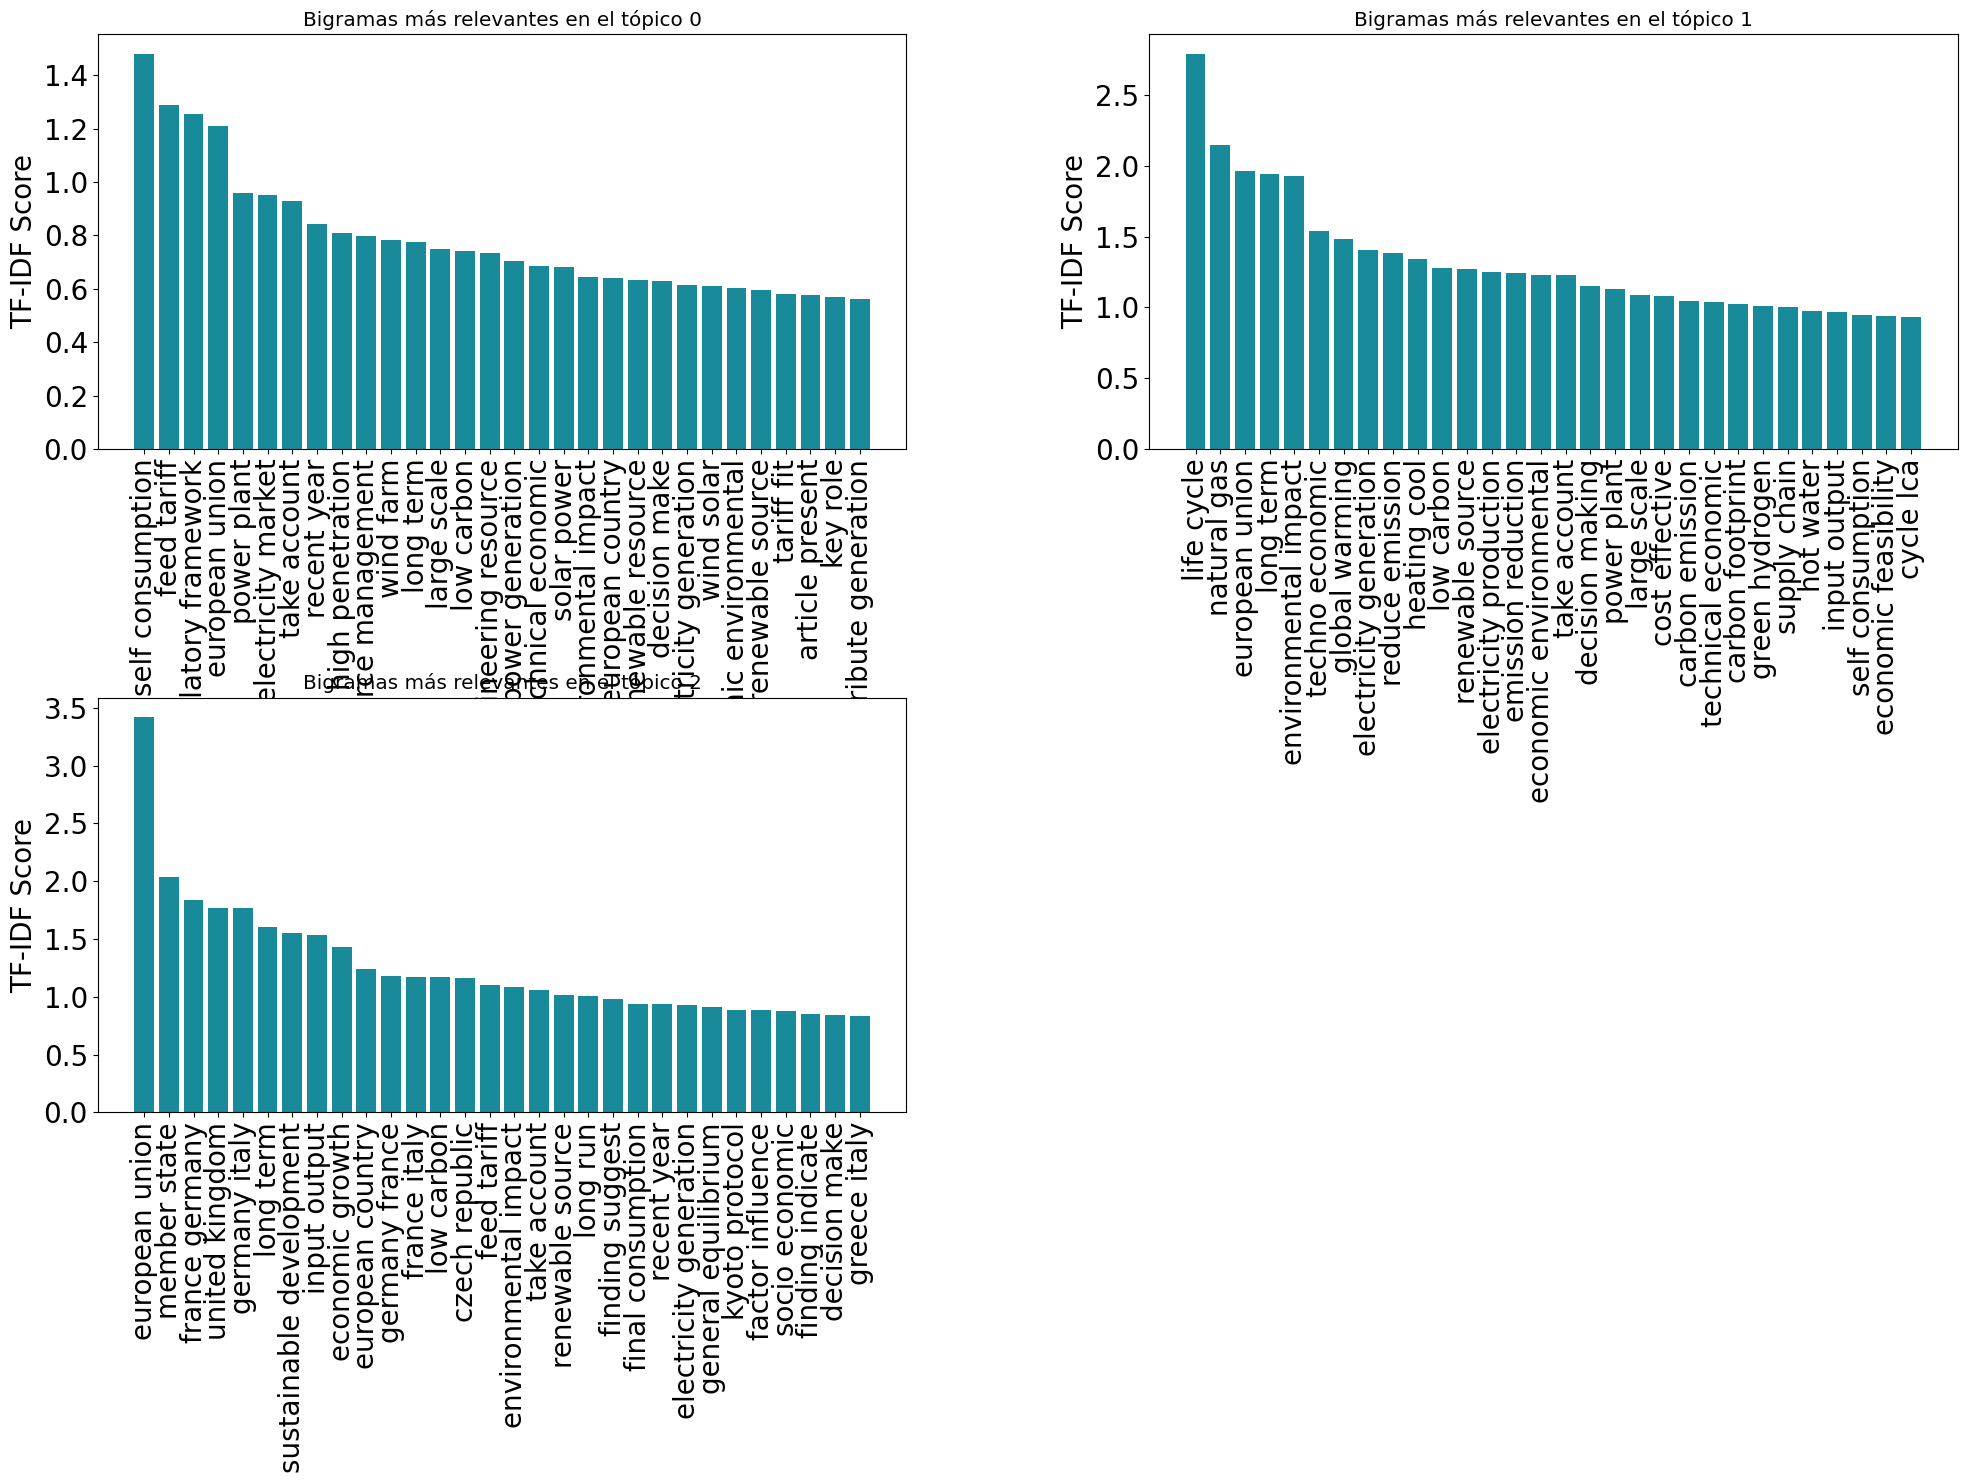

In [41]:
#Vemos todos los bigramas por tópico juntos en la misma visualización para una mejor interpretación
def plot_bigramas_todos_topicos(textos, top_n=30):
    topicos = sorted(textos['topic_dominant'].unique())
    cols = 2
    rows = (len(topicos) + 1) // cols
    fig, axs = plt.subplots(rows, cols, figsize=(24, rows * 7))
    plt.rcParams.update({'font.size': 12})

    # Ensure axs is always iterable and flat for consistent indexing
    if rows * cols == 1: # Case with a single subplot (e.g., 1 topic, 1 row, 1 col)
        axs_flat = [axs]
    else: # Case with multiple subplots
        axs_flat = axs.flatten()

    for idx, topico in enumerate(topicos):
        topic_df = textos[textos['topic_dominant'] == topico]
        dft = topic_df['lemmas_str'].dropna().astype(str)

        vectorizer = TfidfVectorizer(use_idf=True, ngram_range=(2, 2))
        tfidf_matrix = vectorizer.fit_transform(dft)
        terms = vectorizer.get_feature_names_out()
        scores = tfidf_matrix.sum(axis=0).A1
        result = dict(zip(terms, scores))

        sorted_results = sorted(result.items(), key=itemgetter(1), reverse=True)
        df_top = pd.DataFrame(sorted_results[:top_n], columns=['Bigrama', 'TF-IDF'])

        ax = axs_flat[idx] # Use the flattened array for indexing
        ax.bar(df_top['Bigrama'], df_top['TF-IDF'], color='#198A99')
        ax.set_xticklabels(df_top['Bigrama'], rotation=90)
        ax.set_title(f'Bigramas más relevantes en el tópico {topico}')
        ax.set_ylabel('TF-IDF Score')

    # Ocultar subplots vacíos if len(topicos) is less than the total number of subplots created
    num_total_plots = rows * cols
    if len(topicos) < num_total_plots:
        for i in range(len(topicos), num_total_plots):
            axs_flat[i].set_visible(False)

    plt.subplots_adjust(hspace=0.6, wspace=0.3)
    plt.show()

plot_bigramas_todos_topicos(textos)


TRIGRAMAS POR TÓPICOS

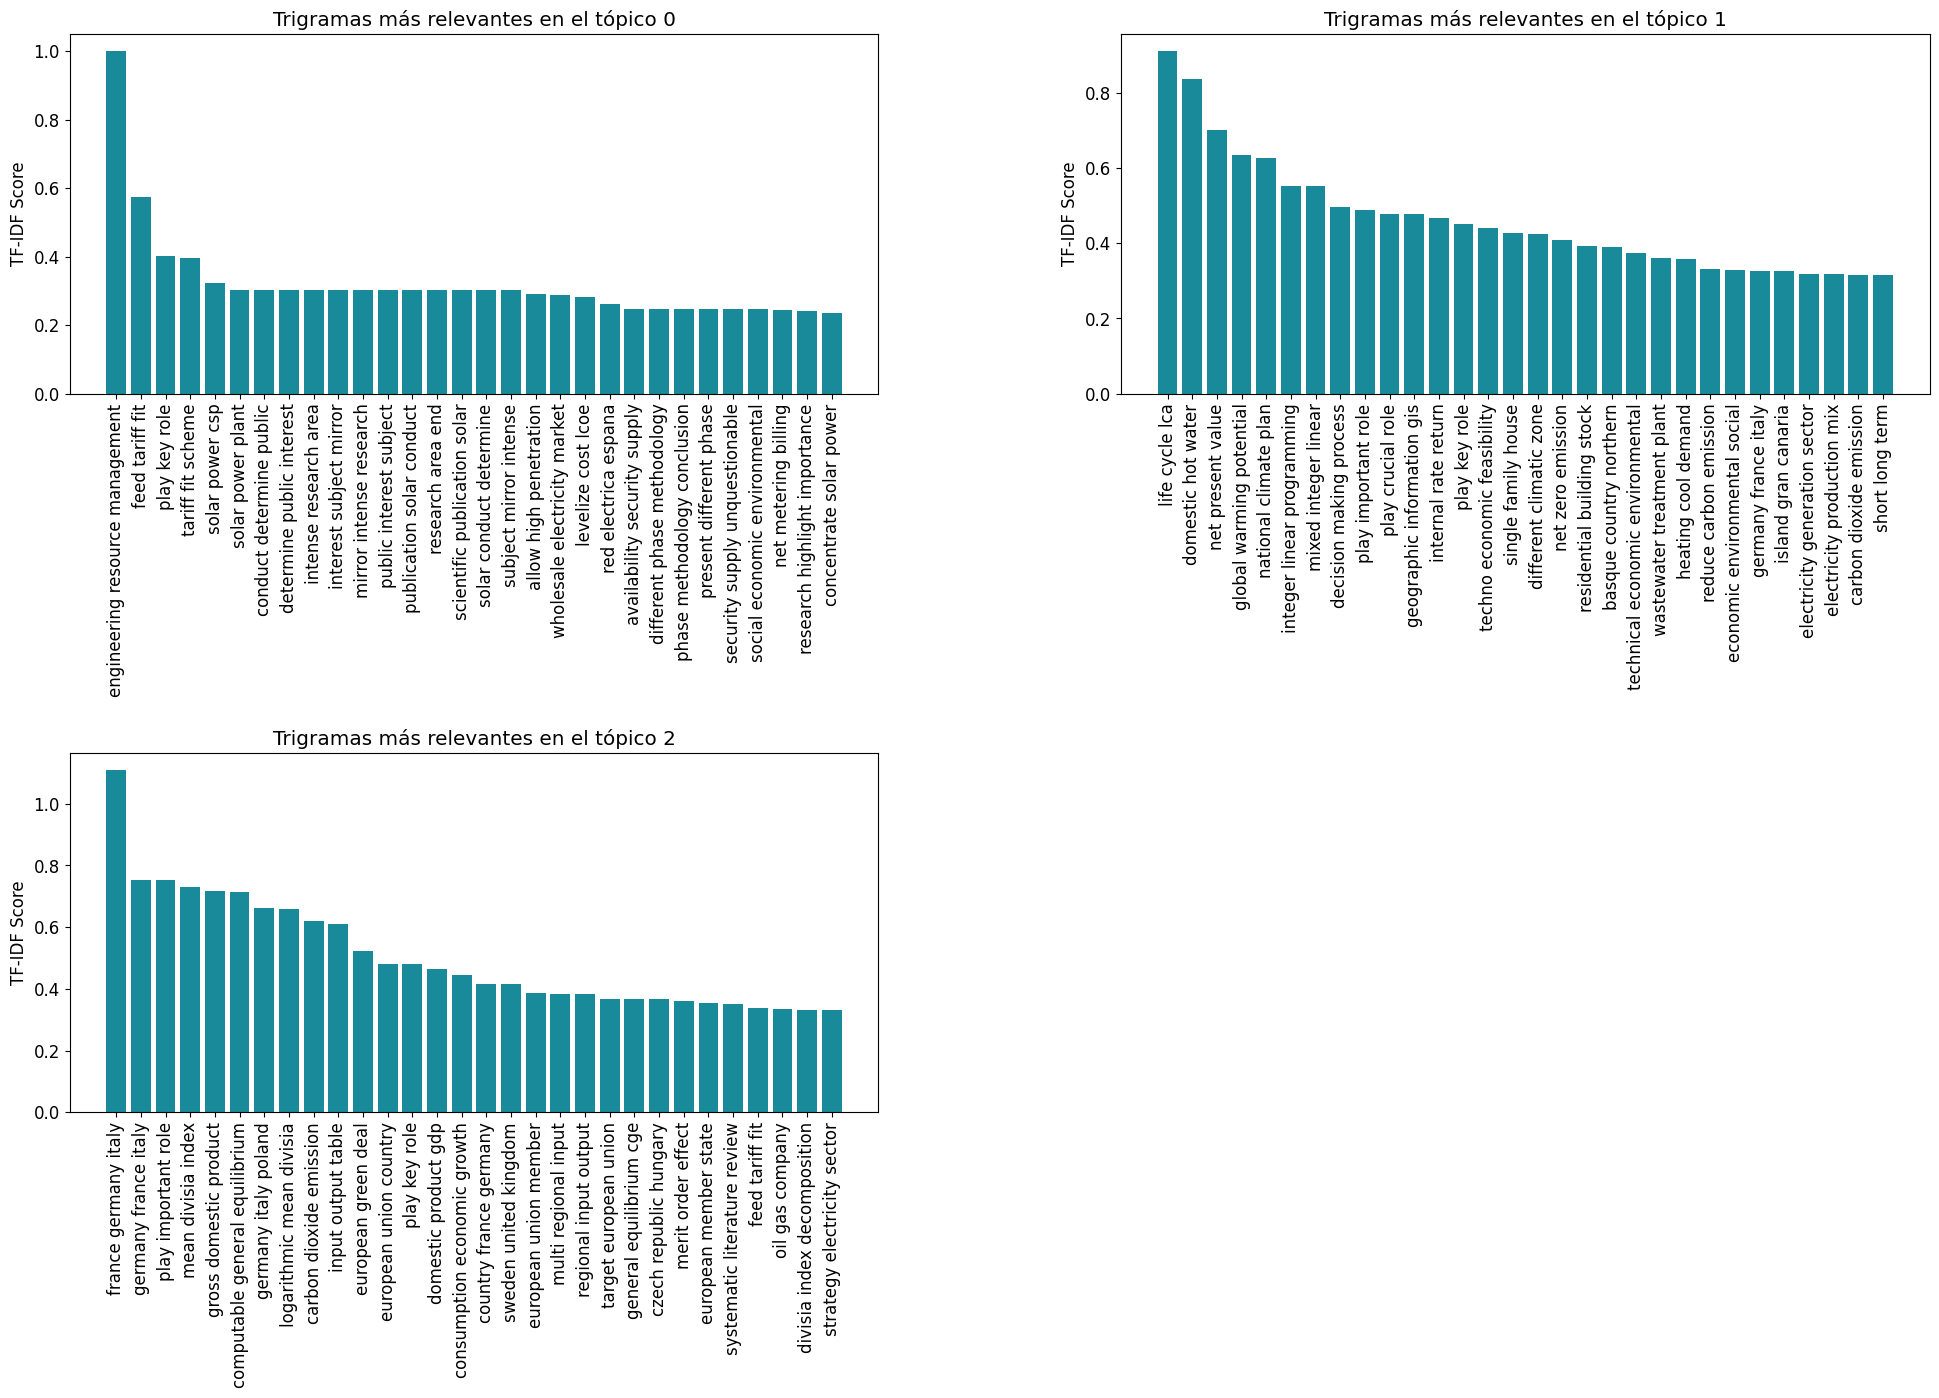

In [42]:
def plot_trigramas_todos_topicos(textos, top_n=30):
    topicos = sorted(textos['topic_dominant'].unique())
    cols = 2
    rows = (len(topicos) + 1) // cols
    fig, axs = plt.subplots(rows, cols, figsize=(24, rows * 7))
    plt.rcParams.update({'font.size': 12})

    # Ensure axs is always iterable and flat for consistent indexing
    if rows * cols == 1: # Case with a single subplot (e.g., 1 topic, 1 row, 1 col)
        axs_flat = [axs]
    else: # Case with multiple subplots
        axs_flat = axs.flatten()

    for idx, topico in enumerate(topicos):
        topic_df = textos[textos['topic_dominant'] == topico]
        dft = topic_df['lemmas_str'].dropna().astype(str)

        vectorizer = TfidfVectorizer(use_idf=True, ngram_range=(3, 3))
        tfidf_matrix = vectorizer.fit_transform(dft)
        terms = vectorizer.get_feature_names_out()
        scores = tfidf_matrix.sum(axis=0).A1
        result = dict(zip(terms, scores))

        sorted_results = sorted(result.items(), key=itemgetter(1), reverse=True)
        df_top = pd.DataFrame(sorted_results[:top_n], columns=['Trigrama', 'TF-IDF'])

        ax = axs_flat[idx] # Use the flattened array for indexing
        ax.bar(df_top['Trigrama'], df_top['TF-IDF'], color='#198A99')
        ax.set_xticklabels(df_top['Trigrama'], rotation=90)
        ax.set_title(f'Trigramas más relevantes en el tópico {topico}')
        ax.set_ylabel('TF-IDF Score')

    # Ocultar subplots vacíos if len(topicos) is less than the total number of subplots created
    num_total_plots = rows * cols
    if len(topicos) < num_total_plots:
        for i in range(len(topicos), num_total_plots):
            axs_flat[i].set_visible(False)

    plt.subplots_adjust(hspace=1, wspace=0.3)
    plt.show()

plot_trigramas_todos_topicos(textos)


Tras el análisis de N-gramas, el modelado de tópicos con LDA y la visualización de palabras clave, bigramas y trigramas por tópico, se identifican tres grandes líneas temáticas en la literatura académica sobre la transición energética en España.


El Tópico 1 es el más representado en el corpus (40,3%) y agrupa investigaciones orientadas al análisis del ciclo de vida, la huella de carbono y la descarbonización sectorial, con términos dominantes como emission, reduce, demand y potential, y expresiones recurrentes como life cycle assessment, reduce emission o net zero emission. El Tópico 2 (39,8%) recoge estudios de carácter político e institucional, centrados en la gobernanza energética europea, con términos como country, european, germany y sector, y expresiones como european union, member state o european green deal. El Tópico 0 (22,6%) representa la línea más técnico-regulatoria, agrupando trabajos sobre mercado eléctrico, inversión renovable y marcos normativos, con términos como electricity, power, generation, framework y cost, y expresiones como electricity generation, regulatory framework o feed-in tariff.

# 4. ANÁLISIS TEMPORAL Y PROYECCIÓN ARIMA

Se construye una serie temporal con el número de publicaciones anuales por tópico identificado en el LDA.

## 4.1 Series temporales por tópico

In [43]:
# Se excluyen el año 2026, por estar incompleto, para no distorsionar la tendencia
AÑO_MIN_SERIE   = int(textos['Year'].min())
AÑO_MAX_SERIE   = 2025
AÑO_PROY_FIN    = 2030

textos_serie    = textos[textos['Year'] <= AÑO_MAX_SERIE].copy()
topicos_unicos  = sorted(textos_serie['topic_dominant'].unique())
años_hist       = list(range(AÑO_MIN_SERIE, AÑO_MAX_SERIE + 1))
años_proy       = list(range(AÑO_MAX_SERIE + 1, AÑO_PROY_FIN + 1))

series_topicos = {}
for t in topicos_unicos:
    serie = (textos_serie[textos_serie['topic_dominant'] == t]
             .groupby('Year').size()
             .reindex(años_hist, fill_value=0))
    series_topicos[t] = serie
    print(f"Tópico {t}: {serie.sum()} artículos en {len(serie)} años "
          f"({AÑO_MIN_SERIE}–{AÑO_MAX_SERIE})")


Tópico 0: 221 artículos en 26 años (2000–2025)
Tópico 1: 383 artículos en 26 años (2000–2025)
Tópico 2: 384 artículos en 26 años (2000–2025)


## 4.2 Test de Dickey-Fuller Aumentado (ADF)

El test ADF contrasta la hipótesis nula de que la serie tiene raíz unitaria (no es estacionaria).
Si el p-valor < 0.05 rechazamos H₀ → la serie es estacionaria → el modelo ARIMA usará d=0.
En caso contrario, auto_arima aplicará diferenciación (d≥1) para estacionarizar la serie.

In [44]:
print("TEST ADF — ESTACIONARIEDAD POR TÓPICO")

resultados_adf = {}
for t, serie in series_topicos.items():
    stat, pval, _, _, crit, _ = adfuller(serie.values)
    estacionaria = pval < 0.05
    resultados_adf[t] = {'stat': stat, 'pval': pval, 'estacionaria': estacionaria}
    print(f"\nTópico {t}:")
    print(f"  Estadístico ADF : {stat:.4f}")
    print(f"  p-valor         : {pval:.4f}")
    print(f"  Valores críticos: 1% = {crit['1%']:.3f} | 5% = {crit['5%']:.3f} | 10% = {crit['10%']:.3f}")
    print(f"  Resultado       : {'✓ Estacionaria (d=0)' if estacionaria else '✗ No estacionaria → se diferenciará (d≥1)'}")


TEST ADF — ESTACIONARIEDAD POR TÓPICO

Tópico 0:
  Estadístico ADF : 2.2877
  p-valor         : 0.9989
  Valores críticos: 1% = -3.924 | 5% = -3.068 | 10% = -2.674
  Resultado       : ✗ No estacionaria → se diferenciará (d≥1)

Tópico 1:
  Estadístico ADF : 1.6884
  p-valor         : 0.9981
  Valores críticos: 1% = -3.924 | 5% = -3.068 | 10% = -2.674
  Resultado       : ✗ No estacionaria → se diferenciará (d≥1)

Tópico 2:
  Estadístico ADF : 3.1832
  p-valor         : 1.0000
  Valores críticos: 1% = -3.889 | 5% = -3.054 | 10% = -2.667
  Resultado       : ✗ No estacionaria → se diferenciará (d≥1)


## 4.3 Ajuste ARIMA y proyección 2025–2030

Se utiliza auto_arima para seleccionar los parámetros óptimos p, d, q mediante el criterio AIC.
La proyección se realiza con statsmodels para obtener el intervalo de confianza al 95%.

In [45]:
print("SELECCIÓN DE PARÁMETROS ARIMA — CRITERIO AIC")

modelos   = {}
preds     = {}
conf_ints = {}

for t, serie in series_topicos.items():
    modelo_auto = auto_arima(
        serie.values,
        start_p=1,
        max_p=3,
        start_q=0,
        max_q=2,
        d=None,
        seasonal=False,
        information_criterion='aic',
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore'
    )
    p, d, q = modelo_auto.order
    print(f"\nTópico {t}: ARIMA({p},{d},{q})  |  AIC = {modelo_auto.aic():.2f}")

    modelo_sm = ARIMA(serie.values, order=(p, d, q)).fit()
    forecast  = modelo_sm.get_forecast(steps=len(años_proy))
    pred_mean = np.maximum(forecast.predicted_mean, 0)
    ci        = forecast.conf_int(alpha=0.05)
    ci[:, 0]  = np.maximum(ci[:, 0], 0)

    modelos[t]   = {'orden': (p, d, q), 'aic': modelo_auto.aic()}
    preds[t]     = pred_mean
    conf_ints[t] = ci

SELECCIÓN DE PARÁMETROS ARIMA — CRITERIO AIC

Tópico 0: ARIMA(1,1,0)  |  AIC = 144.94

Tópico 1: ARIMA(1,2,0)  |  AIC = 161.02

Tópico 2: ARIMA(2,2,1)  |  AIC = 162.00


## 4.4 Tabla resumen de modelos

In [46]:
filas = []
for t in topicos_unicos:
    p, d, q = modelos[t]['orden']
    filas.append({
        'Tópico'              : t,
        'Estacionaria (ADF)'  : 'Sí' if resultados_adf[t]['estacionaria'] else 'No',
        'ARIMA(p,d,q)'        : f'({p},{d},{q})',
        'AIC'                 : round(modelos[t]['aic'], 2),
        'Proy. 2030 (arts.)'  : round(preds[t][-1], 1)
    })

df_res = pd.DataFrame(filas)
print(df_res.to_string(index=False))


 Tópico Estacionaria (ADF) ARIMA(p,d,q)    AIC  Proy. 2030 (arts.)
      0                 No      (1,1,0) 144.94                28.5
      1                 No      (1,2,0) 161.02               125.6
      2                 No      (2,2,1) 162.00                89.3


## 4.5 Visualización: evolución histórica y proyección

Cada gráfico muestra la serie histórica observada (línea continua), la proyección ARIMA (línea discontinua)
y el intervalo de confianza al 95% (banda sombreada), siguiendo el estilo de Zou et al. (2024).

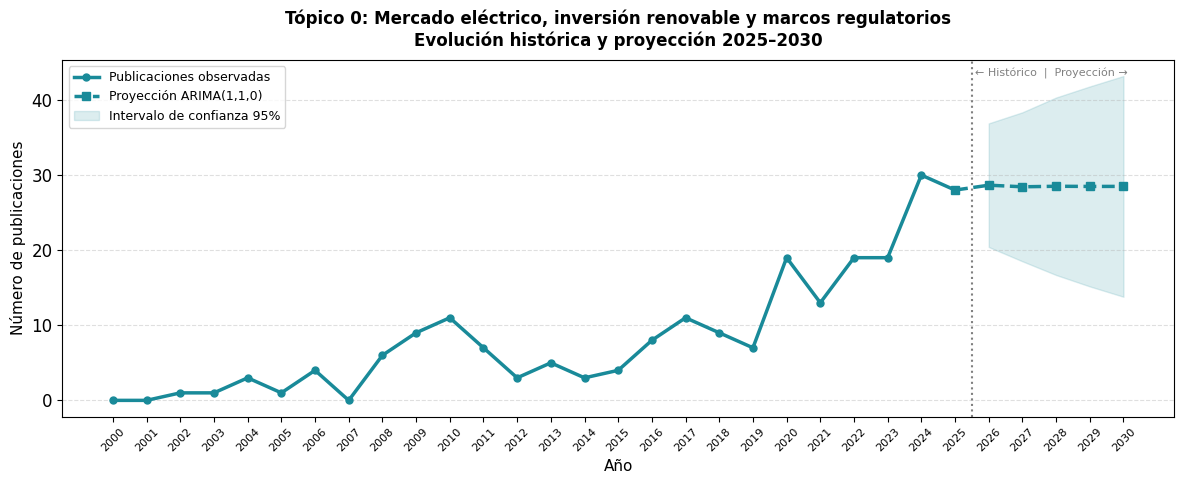

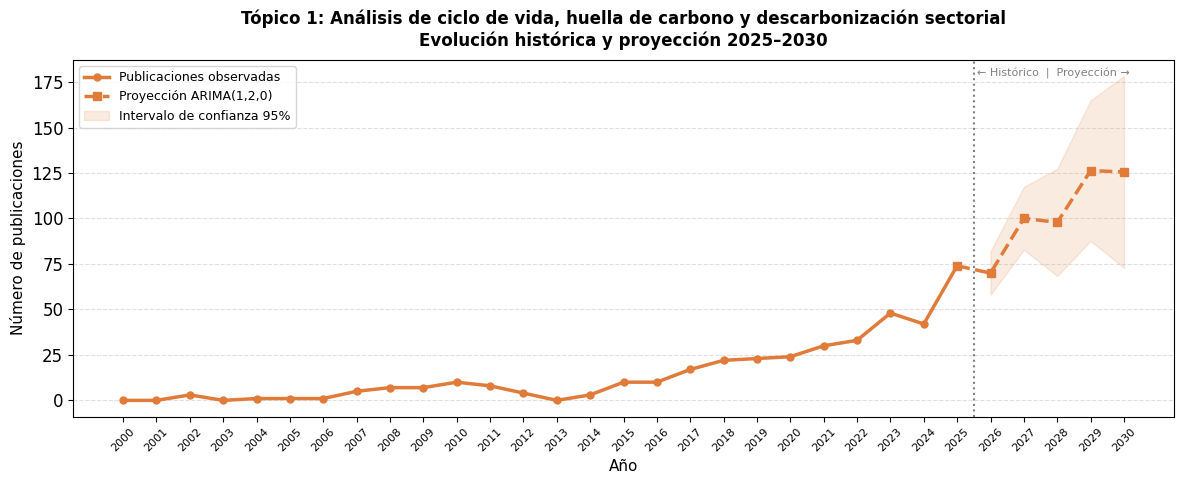

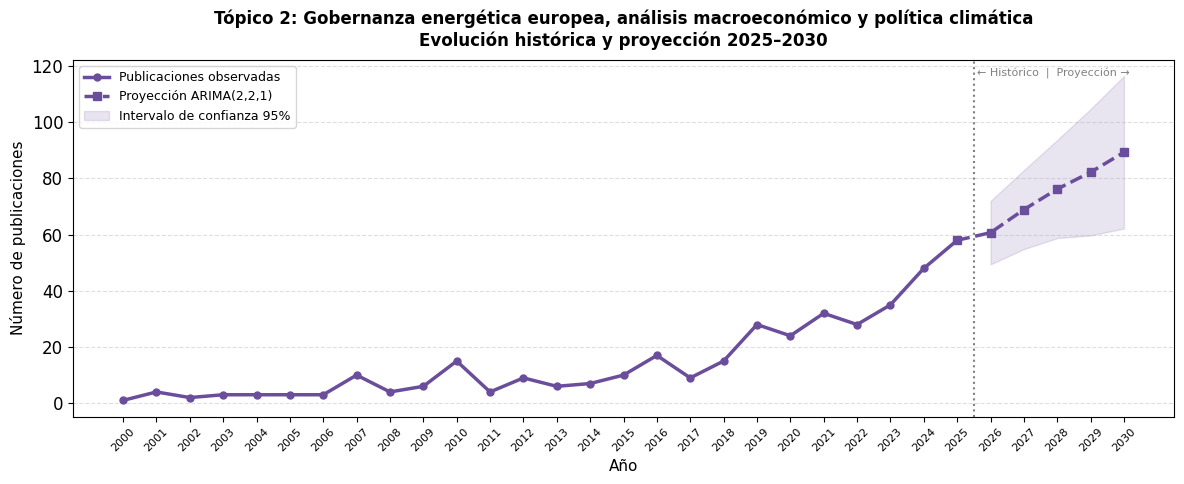

In [47]:
# Etiquetas interpretativas de cada tópico (ajusta si cambias K)
etiquetas_topico = {
    0: "Mercado eléctrico, inversión renovable y marcos regulatorios",
    1: "Análisis de ciclo de vida, huella de carbono y descarbonización sectorial",
    2: "Gobernanza energética europea, análisis macroeconómico y política climática"
}

COLORES = ['#198A99', '#E07B39', '#6B4E9B', '#2E8B57', '#C0392B', '#F39C12']

for idx, t in enumerate(topicos_unicos):
    serie  = series_topicos[t]
    pred   = preds[t]
    ci     = conf_ints[t]
    p, d, q = modelos[t]['orden']
    color  = COLORES[idx % len(COLORES)]
    label  = etiquetas_topico.get(t, f'Tópico {t}')

    fig, ax = plt.subplots(figsize=(12, 5))

    # ── Serie histórica ────────────────────────────────────────
    ax.plot(años_hist, serie.values,
            color=color, linewidth=2.5, marker='o', markersize=5,
            label='Publicaciones observadas')

    # ── Proyección ─────────────────────────────────────────────
    # Unimos el último punto histórico con el primero proyectado para continuidad visual
    ax.plot([años_hist[-1]] + años_proy,
            [serie.values[-1]] + list(pred),
            color=color, linewidth=2.5, linestyle='--',
            marker='s', markersize=6,
            label=f'Proyección ARIMA({p},{d},{q})')

    # ── Intervalo de confianza 95% ─────────────────────────────
    ax.fill_between(años_proy, ci[:, 0], ci[:, 1],
                    color=color, alpha=0.15,
                    label='Intervalo de confianza 95%')

    # ── Línea vertical separadora ──────────────────────────────
    ax.axvline(x=AÑO_MAX_SERIE + 0.5, color='gray',
               linestyle=':', linewidth=1.5)
    ax.text(AÑO_MAX_SERIE + 0.6,
            ax.get_ylim()[1] * 0.95,
            '← Histórico  |  Proyección →',
            fontsize=8, color='gray')

    ax.set_title(f'Tópico {t}: {label}\nEvolución histórica y proyección 2025–2030',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Año', fontsize=11)
    ax.set_ylabel('Número de publicaciones', fontsize=11)
    ax.set_xticks(años_hist + años_proy)
    ax.set_xticklabels([str(a) for a in años_hist + años_proy],
                       rotation=45, fontsize=8)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


## 4.6 Gráfico comparativo: todos los tópicos

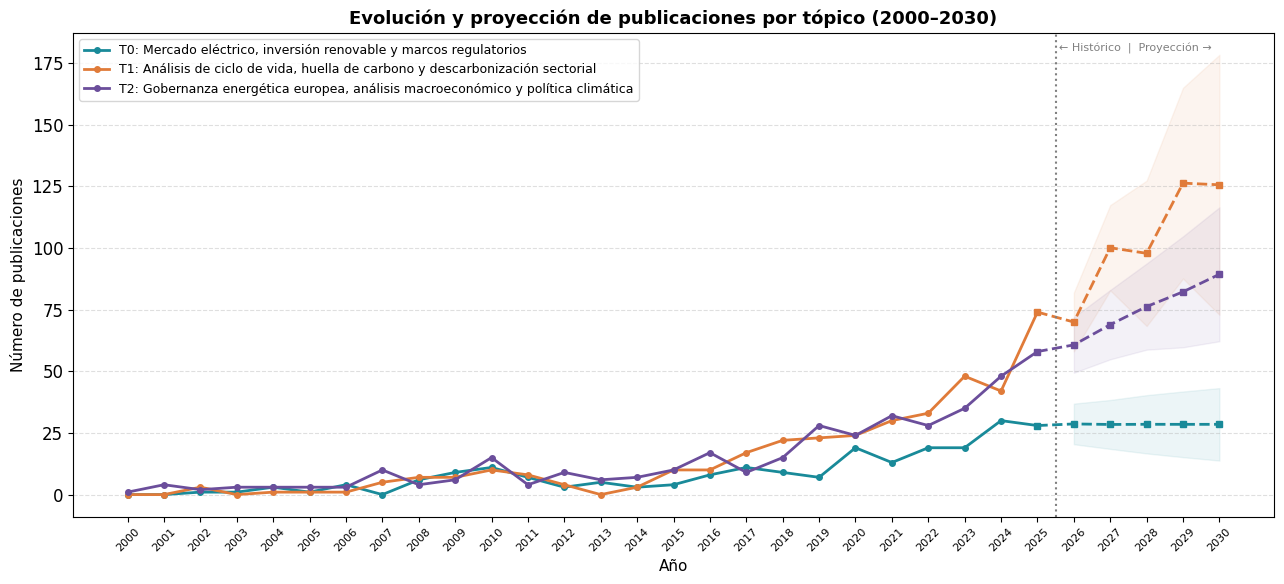

In [48]:
fig, ax = plt.subplots(figsize=(13, 6))

for idx, t in enumerate(topicos_unicos):
    serie = series_topicos[t]
    color = COLORES[idx % len(COLORES)]
    label = etiquetas_topico.get(t, f'Tópico {t}')

    ax.plot(años_hist, serie.values,
            color=color, linewidth=2, marker='o', markersize=4,
            label=f'T{t}: {label}')

    ax.plot([años_hist[-1]] + años_proy,
            [serie.values[-1]] + list(preds[t]),
            color=color, linewidth=2, linestyle='--',
            marker='s', markersize=5)

    ax.fill_between(años_proy,
                    conf_ints[t][:, 0], conf_ints[t][:, 1],
                    color=color, alpha=0.08)

ax.axvline(x=AÑO_MAX_SERIE + 0.5, color='gray', linestyle=':', linewidth=1.5)
ax.text(AÑO_MAX_SERIE + 0.6, ax.get_ylim()[1] * 0.96,
        '← Histórico  |  Proyección →', fontsize=8, color='gray')

ax.set_title('Evolución y proyección de publicaciones por tópico (2000–2030)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Número de publicaciones', fontsize=11)
ax.set_xticks(años_hist + años_proy)
ax.set_xticklabels([str(a) for a in años_hist + años_proy], rotation=45, fontsize=8)
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
